:
# Visualization Google Colab Of Self-Reported Scores
@Author: Philippe Wyder  
(Modified by Alexey Yermakov)
---



## Imports / Flags


In [1]:
%load_ext autoreload
%autoreload 2

import os
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import plotly.express as px
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import matplotlib.font_manager as fm
from plotly.subplots import make_subplots
warnings.filterwarnings('ignore')

from visualize_scores_helpers import *

# DPI for publication-quality figures
NEURIPS_DPI = 300

# We'll populate these after loading data
GLOBAL_MODEL_COLORS = {}
GLOBAL_MODEL_MARKERS = {}
GLOBAL_MODEL_PATTERNS = {}


Using font family: ['Open Sans']


# Load Data

In [2]:
# Paths to data
seismo_csv = Path(os.getcwd()) / 'self_reported_seismo.csv'

# Load the data
data = load_sheets_data([seismo_csv])

# Rename seismo key to Seismic_Wavefields
data = {k.replace('seismo', 'Seismic_Wavefields'): v for k, v in data.items()}

# Create global color mapping for all models
if data:
    all_models = set()
    for df in data.values():
        all_models.update(df['Model'].unique())

    GLOBAL_MODEL_COLORS, GLOBAL_MODEL_MARKERS, GLOBAL_MODEL_PATTERNS = create_model_color_mapping(list(all_models))
    print(f"\nCreated color mapping for {len(GLOBAL_MODEL_COLORS)} models")
    print(f"Created marker mapping for {len(GLOBAL_MODEL_MARKERS)} models")
    print(f"Created pattern mapping for {len(GLOBAL_MODEL_PATTERNS)} models")

seismo loaded: 16 rows (after cleaning), 14 columns

Replaced NaN values with -100.0 in seismo

Created color mapping for 16 models
Created marker mapping for 16 models
Created pattern mapping for 16 models


# Basic Data Exploration

In [3]:
# Explore the cleaned data
if data:
    explore_cleaned_data(data)


Sheet: Seismic_Wavefields

Shape: (16, 14)

Models included: ['Baseline Zeros', 'Baseline Average', 'Reservoir', 'KAN', 'HigherOrder DMD', 'Opt DMD', 'PyKoopman', 'LSTM', 'ODE-LSTM', 'Spacetime', 'DeepONet', 'SINDy', 'FNO', 'NeuralODE', 'Moirai', 'Chronos']

First 5 rows:


,Model,avg_score,E1,E2,E3,E4,E5,E6,E7,E8,E9,E10,E11,E12
0,Baseline Zeros,0.000000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,0.00000,0.000000,0.00000,0.000000
1,Baseline Average,0.155667,-0.00050,0.00050,0.00050,0.01800,3.58600,0.02840,-1.7290,0.00560,-0.01540,0.015340,-0.02593,-0.015500
2,Reservoir,-58.504167,0.76000,-100.00000,46.50000,-100.00000,0.00000,50.69000,-100.0000,-100.00000,-100.00000,-100.000000,-100.00000,-100.000000
3,KAN,0.351000,-0.00130,0.00260,0.00020,2.55290,-0.00220,0.13220,0.2906,0.39930,0.08170,0.404500,-0.00220,0.001000
4,HigherOrder DMD,-0.380236,0.00048,-0.00051,0.00016,0.01762,-0.00383,0.02846,0.0056,-1.72948,0.01534,-0.015389,-1.53989,-1.341387



Basic statistics (numeric columns only):


,avg_score,E1,E2,E3,E4,E5,E6,E7,E8,E9,E10,E11,E12
count,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000
mean,-16.185657,-7.706300,-21.324756,-7.289466,-17.751187,-18.812241,-2.523484,-18.112260,-18.661525,-17.190329,-28.977961,-16.865555,-19.795683
std,24.686563,26.996896,41.310918,53.728881,47.031228,47.652128,34.419583,28.848122,40.676936,35.867890,52.359330,28.202272,34.757664
min,-58.504167,-100.000000,-100.000000,-100.000000,-100.000000,-100.000000,-100.000000,-100.000000,-100.000000,-100.000000,-100.000000,-100.000000,-100.000000
25%,-31.640810,-2.081310,-22.342500,-11.082375,-25.426261,-26.828750,-0.813675,-35.380750,-5.204610,-24.564183,-95.740000,-27.706225,-17.801250
50%,-4.053113,-0.001300,0.000000,0.000350,0.024000,-0.001100,0.044230,-2.990778,0.050847,-2.965400,-0.007694,-2.419325,-2.300356
75%,0.204501,0.022860,1.593750,11.556500,10.270750,1.038950,10.117875,0.001400,0.473500,0.028455,8.288250,-0.019998,-0.011625
max,11.528991,17.430000,10.916620,71.826000,30.200000,46.407770,50.690000,8.600000,11.060000,27.430000,27.886580,3.165000,0.140000



Missing values in task scores (E1-E12):
Series([], dtype: int64)

Average score range: -58.50 to 11.53


# Define Bar Plot
Here we define the function for creating the bar plot of the top-few methods & a baseline

All models: ['Baseline Average', 'Baseline Zeros', 'Chronos', 'DeepONet', 'FNO', 'HigherOrder DMD', 'KAN', 'LSTM', 'Moirai', 'NeuralODE', 'ODE-LSTM', 'Opt DMD', 'PyKoopman', 'Reservoir', 'SINDy', 'Spacetime']


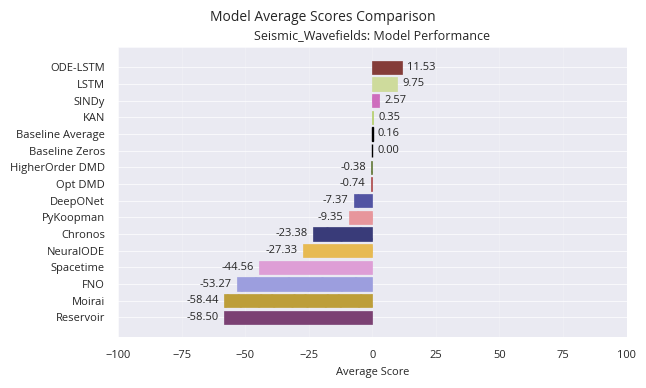

In [4]:
# Create model comparison plots
create_model_comparison_plots(data, size=(6.5, 4), globals=(GLOBAL_MODEL_COLORS, GLOBAL_MODEL_MARKERS, GLOBAL_MODEL_PATTERNS, NEURIPS_DPI))



# Define Spider Plot
Here we define the function for creating the spider plot of the top four methods that dominate the compound score.

In [26]:
import pprint as pp
pp.pprint(GLOBAL_MODEL_COLORS)
pp.pprint(GLOBAL_MODEL_MARKERS)
GLOBAL_MODEL_MARKERS['LSTM'] = '+'
GLOBAL_MODEL_COLORS['LSTM'] = GLOBAL_MODEL_COLORS['FNO']

{'Baseline Average': array([0.41708574, 0.68063053, 0.83823145, 1.        ]),
 'Baseline Zeros': array([0.09019608, 0.39294118, 0.67058824, 1.        ]),
 'Chronos': array([0.22352941, 0.23137255, 0.4745098 , 1.        ]),
 'DeepONet': array([0.32156863, 0.32941176, 0.63921569, 1.        ]),
 'FNO': array([0.61176471, 0.61960784, 0.87058824, 1.        ]),
 'HigherOrder DMD': array([0.38823529, 0.4745098 , 0.22352941, 1.        ]),
 'KAN': array([0.70980392, 0.81176471, 0.41960784, 1.        ]),
 'LSTM': array([0.32156863, 0.32941176, 0.63921569, 1.        ]),
 'Moirai': array([0.74117647, 0.61960784, 0.22352941, 1.        ]),
 'NeuralODE': array([0.90588235, 0.72941176, 0.32156863, 1.        ]),
 'ODE-LSTM': array([0.51764706, 0.23529412, 0.22352941, 1.        ]),
 'Opt DMD': array([0.67843137, 0.28627451, 0.29019608, 1.        ]),
 'PyKoopman': array([0.90588235, 0.58823529, 0.61176471, 1.        ]),
 'Reservoir': array([0.48235294, 0.25490196, 0.45098039, 1.        ]),
 'SINDy': arra

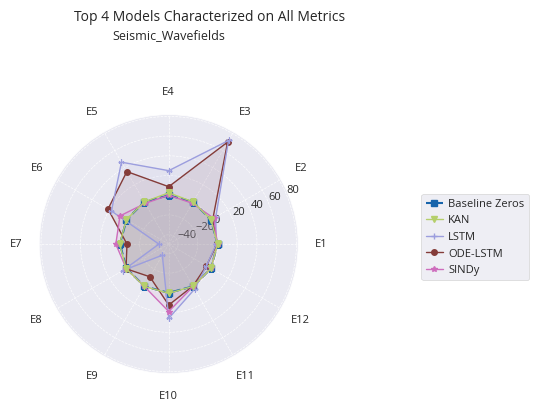

In [27]:
# Create spider plots
create_spider_plots(data, size=(6.5, 3.5), n_top_models=4, globals=(GLOBAL_MODEL_COLORS, GLOBAL_MODEL_MARKERS, GLOBAL_MODEL_PATTERNS, NEURIPS_DPI))

# Barplot Comparison top models per metric per dataset

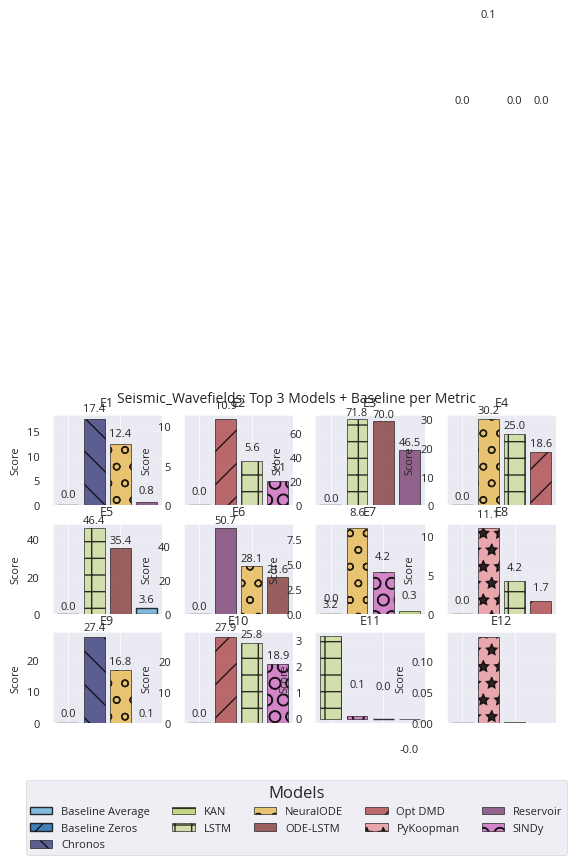

In [6]:
# Create compound bar plots
create_compound_bar_plots(data, size=(6.5, 4), globals=(GLOBAL_MODEL_COLORS, GLOBAL_MODEL_MARKERS, GLOBAL_MODEL_PATTERNS, NEURIPS_DPI))

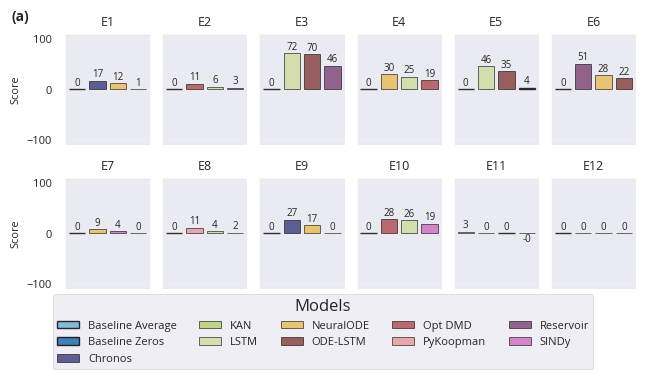

In [7]:
# Create compact compound bar plots
create_compact_compound_bar_plots(data, size=(6.5, 3), globals=(GLOBAL_MODEL_COLORS, GLOBAL_MODEL_MARKERS, GLOBAL_MODEL_PATTERNS, NEURIPS_DPI))

# Condensed Plot with baseline as dashed line across graph

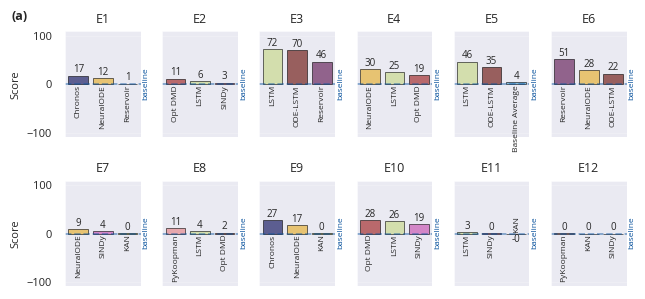

In [8]:
# Create ultra-compact compound bar plots without patterns
create_ultra_compact_bar_plots(data, size=(6.5, 3), use_patterns=False, globals=(GLOBAL_MODEL_COLORS, GLOBAL_MODEL_MARKERS, GLOBAL_MODEL_PATTERNS, NEURIPS_DPI))

# Generate Plots

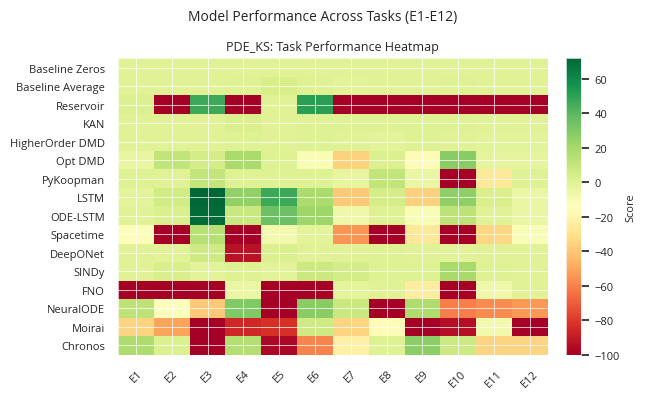

In [9]:
# Create task performance heatmaps
create_task_performance_heatmaps(data, size=(6.5, 4), globals=(GLOBAL_MODEL_COLORS, GLOBAL_MODEL_MARKERS, GLOBAL_MODEL_PATTERNS, NEURIPS_DPI))

# Comparative Analysis

In [10]:
# Create interactive task comparison
create_interactive_task_comparison(data)

# Statistical Analysis

<class 'numpy.ndarray'>
1


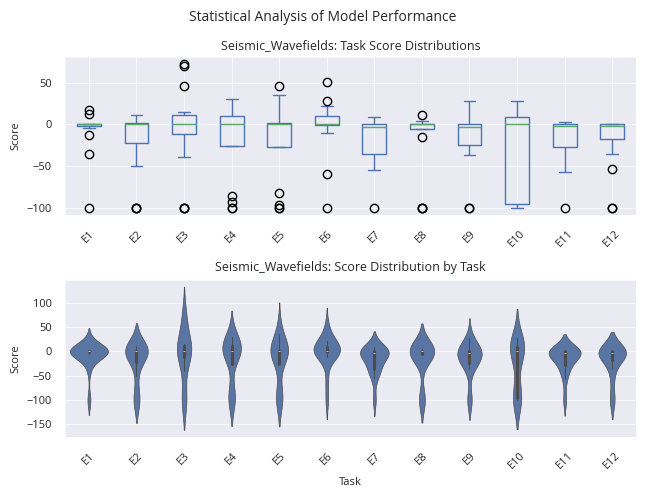


Summary Statistics:

Seismic_Wavefields:
  Number of models: 16
  Average score range: -58.50 to 11.53
  Mean of average scores: -16.19
  Std of average scores: 24.69
  Best performing model: ODE-LSTM (score: 11.53)
  Worst performing model: Reservoir (score: -58.50)


In [11]:
# Perform statistical analysis
statistical_analysis(data, size=(6.5, 5), globals=(GLOBAL_MODEL_COLORS, GLOBAL_MODEL_MARKERS, GLOBAL_MODEL_PATTERNS, NEURIPS_DPI))

# Rankings

In [12]:
# Create model rankings
create_model_rankings(data, globals=(GLOBAL_MODEL_COLORS, GLOBAL_MODEL_MARKERS, GLOBAL_MODEL_PATTERNS, NEURIPS_DPI))


Model Rankings:

Seismic_Wavefields Rankings:
 rank            Model  avg_score
    1         ODE-LSTM  11.528991
    2             LSTM   9.751756
    3            SINDy   2.573670
    4              KAN   0.351000
    5 Baseline Average   0.155667
    6   Baseline Zeros   0.000000
    7  HigherOrder DMD  -0.380236
    8          Opt DMD  -0.736360
    9         DeepONet  -7.369867
   10        PyKoopman  -9.350000
   11          Chronos -23.380000
   12        NeuralODE -27.333333
   13        Spacetime -44.563242
   14              FNO -53.270233
   15           Moirai -58.444167
   16        Reservoir -58.504167


## Rankings: Matplotlib Version

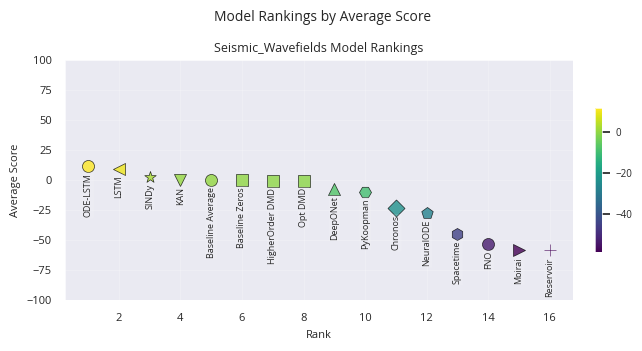


Model Rankings:

Seismic_Wavefields Rankings:
 rank            Model  avg_score
    1         ODE-LSTM  11.528991
    2             LSTM   9.751756
    3            SINDy   2.573670
    4              KAN   0.351000
    5 Baseline Average   0.155667
    6   Baseline Zeros   0.000000
    7  HigherOrder DMD  -0.380236
    8          Opt DMD  -0.736360
    9         DeepONet  -7.369867
   10        PyKoopman  -9.350000
   11          Chronos -23.380000
   12        NeuralODE -27.333333
   13        Spacetime -44.563242
   14              FNO -53.270233
   15           Moirai -58.444167
   16        Reservoir -58.504167



In [13]:
# Create model rankings with Matplotlib
create_model_rankings_matplotlib(data, size=(6.5, 3.5), globals=(GLOBAL_MODEL_COLORS, GLOBAL_MODEL_MARKERS, GLOBAL_MODEL_PATTERNS, NEURIPS_DPI))

# Generate Latex Tables

In [14]:
# Create LaTeX tables
latex_tables = create_latex_performance_tables(data)


LaTeX Table for Seismic_Wavefields
\begin{table}[h!]
\centering
\caption{Model Performance Rankings: Seismic_Wavefields}
\label{tab:seismic_wavefields_rankings}
\begin{adjustbox}{width=\textwidth}
\begin{tabular}{l|r|rrrrrrrrrrrr}
\hline
\textbf{Model} & \textbf{Avg Score} & \textbf{E1} & \textbf{E2} & \textbf{E3} & \textbf{E4} & \textbf{E5} & \textbf{E6} & \textbf{E7} & \textbf{E8} & \textbf{E9} & \textbf{E10} & \textbf{E11} & \textbf{E12} \\
\hline
ODE-LSTM & 11.53 & -0.57 & 2.24 & 69.98 & 8.71 & 35.43 & 21.6 & -7.14 & 0.54 & -11.19 & 12.36 & -0.39 & -5.33 \\
LSTM & 9.75 & -1.36 & 5.63 & \textbf{71.83} & 24.97 & \textbf{46.41} & 17.61 & -39.47 & 4.23 & -36.48 & 25.79 & 3.16 & -5.3 \\
SINDy & 2.57 & -0.0 & 3.12 & -1.68 & 0.07 & -1.74 & 7.62 & 4.18 & 0.26 & 0.07 & 18.89 & 0.1 & 0.0 \\
KAN & 0.35 & -0.0 & 0.0 & 0.0 & 2.55 & -0.0 & 0.13 & 0.29 & 0.4 & 0.08 & 0.4 & -0.0 & 0.0 \\
Baseline Average & 0.16 & -0.0 & 0.0 & 0.0 & 0.02 & 3.59 & 0.03 & -1.73 & 0.01 & -0.02 & 0.02 & -0.03 & -0.02 

,Model,avg_score,E1,E2,E3,E4,E5,E6,E7,E8,E9,E10,E11,E12
8,ODE-LSTM,11.528991,-0.57,2.24,69.98,8.71,35.43,21.6,-7.14,0.54,-11.19,12.36,-0.39,-5.33
7,LSTM,9.751756,-1.36,5.63,71.83,24.97,46.41,17.61,-39.47,4.23,-36.48,25.79,3.16,-5.3
11,SINDy,2.573670,-0.0,3.12,-1.68,0.07,-1.74,7.62,4.18,0.26,0.07,18.89,0.1,0.0
3,KAN,0.351000,-0.0,0.0,0.0,2.55,-0.0,0.13,0.29,0.4,0.08,0.4,-0.0,0.0
1,Baseline Average,0.155667,-0.0,0.0,0.0,0.02,3.59,0.03,-1.73,0.01,-0.02,0.02,-0.03,-0.02
0,Baseline Zeros,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,HigherOrder DMD,-0.380236,0.0,-0.0,0.0,0.02,-0.0,0.03,0.01,-1.73,0.02,-0.02,-1.54,-1.34
5,Opt DMD,-0.736360,-4.26,10.92,4.39,18.57,0.56,-10.81,-35.65,1.72,-15.6,27.89,-3.3,-3.26
10,DeepONet,-7.369867,-0.1,-1.1,6.5,-93.09,2.49,-0.52,-0.66,0.1,-0.66,-1.09,-0.25,-0.05
6,PyKoopman,-9.350000,0.09,0.0,10.54,0.03,0.08,0.06,-3.42,11.06*,-5.27,-100.0,-25.54,0.14*


Note: * indicates the best score for that task

Saved LaTeX table to Seismic_Wavefields_rankings_table.tex

Saved combined LaTeX document to model_rankings_combined.tex


# Save Results

In [15]:
#save_analysis_results(data, save_path='')